# Checkpoint 4 — Questão 2: Gestão inteligente do consumo de energia

**Grupo:** _(preencher: Nome — RA de cada integrante)_  
**SEED do grupo:** `src/config.py` (`SEED_GRUPO`), registrada no README.

Sequência do notebook: **A** estruturas de dados → **B** força bruta → **C** dividir e conquistar → **D** escalabilidade → **E** figuras → **Big O** e a pergunta “1.000 → 1.000.000 registros”.
Todos os algoritmos estão em `src/` (`brute_force.py`, `divide_conquer.py`) e foram implementados pelo grupo, sem funções prontas que resolvam o problema.

In [1]:
import sys, time, math
from datetime import datetime
from pathlib import Path

RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

import matplotlib.pyplot as plt
from src.config import SEED_GRUPO
from src.gerador_q2 import gerar_registros, salvar_registros
from src.estruturas_energia import IndiceEnergia, ESCALA, criticidade_registro
from src.brute_force import forca_bruta_cubica, forca_bruta_quadratica
from src.divide_conquer import dividir_e_conquistar
from src.escalabilidade import (executar_experimento, estimar_expoente, experimento_viabilidade,
                                ALGORITMOS, TAMANHOS_PADRAO)
from src.visualizacao_q2 import (figura_serie_temporal, figura_divide_conquer,
                                 figura_escalabilidade, figura_estruturas)

SEED = SEED_GRUPO
PASTA_FIG = RAIZ / "figures" / "questao2"
print("SEED =", SEED)

SEED = 1


## Parte A — Estruturação dos dados

**Dados sintéticos e reprodutíveis** (`src/gerador_q2.py`, tudo sai de `random.Random(SEED)`):
5 regiões × 2 unidades × 720 horas (30 dias a partir de 01/01/2026) = **7 200 registros** com
`timestamp, regiao, unidade, consumo_mwh, capacidade_mwh, prioridade, custo_rs_mwh`.

* consumo = capacidade-base × uso médio × **perfil diário** (pico às 18–20 h) × fator de **fim de semana** × **ondas de calor** (+20% a +45% por 6–30 h) × ruído;
* capacidade = capacidade-base × variação **solar** diária × **indisponibilidades** (−10% a −25% por 4–12 h);
* custo (R$/MWh) sobe com a utilização (escassez).

In [2]:
registros = gerar_registros(SEED, n_horas=720, unidades_por_regiao=2)
salvar_registros(registros, RAIZ / "data", SEED, {"n_horas": 720, "unidades_por_regiao": 2})
ix = IndiceEnergia(registros)

print(f"{len(registros)} registros | {len(ix.serie)} horas | regiões: {sorted(ix.regioes)}")
print("primeiros registros:")
for r in registros[:3]: print("  ", r)

7200 registros | 720 horas | regiões: ['Centro-Oeste', 'Nordeste', 'Norte', 'Sudeste', 'Sul']
primeiros registros:
   Registro(timestamp=datetime.datetime(2026, 1, 1, 0, 0), regiao='Centro-Oeste', unidade='CE-01', consumo=75.13, capacidade=90.73, prioridade=2, custo=277.72)
   Registro(timestamp=datetime.datetime(2026, 1, 1, 0, 0), regiao='Centro-Oeste', unidade='CE-02', consumo=88.64, capacidade=119.55, prioridade=2, custo=224.13)
   Registro(timestamp=datetime.datetime(2026, 1, 1, 0, 0), regiao='Nordeste', unidade='NO-01', consumo=78.44, capacidade=107.04, prioridade=1, custo=214.92)


### Estruturas usadas e a operação em que cada uma é vantajosa

| Estrutura | Onde (em `IndiceEnergia`) | Operação em que ganha | Custo |
|---|---|---|---|
| `list` ordenada por tempo | `registros`, `serie`, `timestamps` | acesso por posição e **fatias contíguas** (um intervalo de tempo = índices contíguos) | O(1) / O(k) |
| `bisect` sobre `list` | `indices_do_intervalo` | selecionar `[t0, t1]` por data sem varrer tudo | O(log n) |
| `list` de somas prefixo | `soma_criticidade` | soma de criticidade de **qualquer** intervalo | O(1) por consulta |
| `dict` (região → índices) | `consumo_por_regiao` | ir direto aos registros da região | O(1) + O(k) |
| `dict` (hora do dia → índices) | `perfil_horario` | consumo por horário | O(1) + O(k) |
| `tuple` (`NamedTuple`) | `Registro`, `PontoHorario` | imutável e *hashable*: não se altera por engano | O(1) |
| `set` | `horas_criticas_por_regiao` | “esta hora é crítica?” e **interseção** entre regiões | O(1) / O(min(a,b)) |
| `heapq` (min-heap de tamanho k) | `top_picos` | os k maiores picos sem ordenar tudo | O(n log k) vs O(n log n) |

In [3]:
print("Consumo por região (MWh):")
for regiao, v in ix.consumo_total_por_regiao().items(): print(f"  {regiao:13} {v:12,.0f}")

perfil = ix.perfil_horario()
print(f"\nHora do dia com maior consumo médio: {max(perfil, key=perfil.get)}h")

print("\nTop-3 picos (heap):")
for p in ix.top_picos(3): print(f"  {p.timestamp:%d/%m %Hh}  {p.consumo:.0f} MWh")

criticas = ix.horas_criticas_por_regiao(0.90)
print("\nHoras com utilização ≥ 90% por região:", {r: len(h) for r, h in sorted(criticas.items())})
print("Períodos contínuos no Sudeste (início, fim em horas):", IndiceEnergia.agrupar_periodos(criticas["Sudeste"])[:6], "...")
print("Horas críticas simultâneas Sudeste ∩ Sul:", len(ix.horas_criticas_em_comum(["Sudeste", "Sul"], 0.90)))

i, j = ix.indices_do_intervalo(datetime(2026, 1, 10), datetime(2026, 1, 12, 23))
print(f"\nSeleção de 10/01 a 12/01 (bisect): horas {i}..{j} -> criticidade somada (prefixos) = {ix.soma_criticidade(i, j)/ESCALA:,.0f}")

Consumo por região (MWh):
  Centro-Oeste       104,723
  Nordeste           109,680
  Norte              108,703
  Sudeste            114,514
  Sul                117,688

Hora do dia com maior consumo médio: 19h

Top-3 picos (heap):
  20/01 18h  998 MWh
  20/01 20h  996 MWh
  20/01 19h  981 MWh

Horas com utilização ≥ 90% por região: {'Centro-Oeste': 28, 'Nordeste': 12, 'Norte': 15, 'Sudeste': 171, 'Sul': 56}
Períodos contínuos no Sudeste (início, fim em horas): [(16, 21), (23, 23), (41, 48), (65, 69), (88, 97), (111, 111)] ...
Horas críticas simultâneas Sudeste ∩ Sul: 35

Seleção de 10/01 a 12/01 (bisect): horas 216..287 -> criticidade somada (prefixos) = -20,857


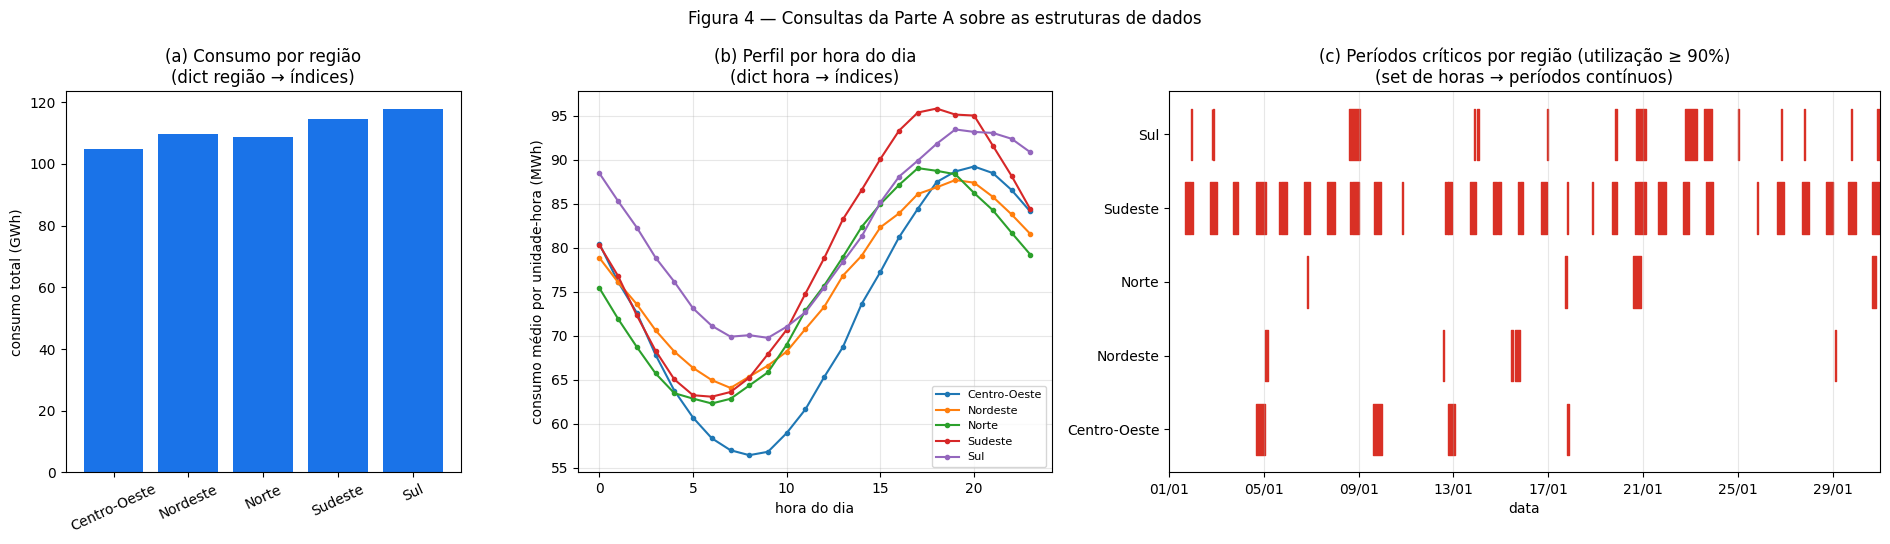

In [4]:
fig4 = figura_estruturas(ix, 0.90, PASTA_FIG / 'fig4_estruturas.png'); plt.show()

### Função de criticidade (definição do grupo)

Para cada registro, com $u=\text{consumo}/\text{capacidade}$:

$$\text{crit}=\text{prioridade}\cdot\big[100\,(u-0{,}80)+3\cdot100\cdot\max(0,u-1)\big]+10\left(\tfrac{\text{custo}}{300}-1\right)$$

A criticidade horária do sistema é a soma das unidades naquela hora (inteiros na escala 1/100, para evitar erros de ponto flutuante).

**Por que a criticidade precisa ter sinal.** Se todas as horas tivessem criticidade positiva (como em `consumo + penalidade + prioridade`), o maior intervalo acumulado seria
sempre a série inteira — o problema seria trivial. Com $u<0{,}80$ (folga) a criticidade é **negativa**: horas tranquilas *reduzem* o acumulado, e o problema passa a ser achar o **trecho contínuo em que a pressão sobre a capacidade supera a folga**.
A prioridade multiplica (pressão sobre unidade essencial pesa mais), o excesso ($u>1$) é penalizado 3× e o custo alto sinaliza escassez.

In [5]:
serie = ix.serie_criticidade()
print("horas:", len(serie), "| positivas:", sum(v > 0 for v in serie), "| negativas:", sum(v < 0 for v in serie))

horas: 720 | positivas: 203 | negativas: 517


## Parte B — Força bruta

O problema: dada $a[0..n-1]$ (com valores positivos e negativos), achar $i\le j$ que maximize $a[i]+\dots+a[j]$.
Há $n(n+1)/2$ intervalos e a força bruta os **examina explicitamente**:

* `forca_bruta_cubica`: três laços (início, fim, soma do trecho). Cada intervalo é somado do zero ⇒ $\sum(\text{comprimento})=\frac{n(n+1)(n+2)}{6}$ somas ⇒ $\Theta(n^3)$.
* `forca_bruta_quadratica`: dois laços; a soma de $[i,j]$ é a de $[i,j-1]$ mais $a[j]$ ⇒ 1 soma por intervalo ⇒ $\frac{n(n+1)}{2}$ ⇒ $\Theta(n^2)$.

**Desempate** (igual nos três algoritmos, para poderem ser comparados): maior soma; depois o intervalo mais curto; depois o que começa mais cedo.

In [6]:
def mostrar(nome, r):
    print(f"{nome:22} [{r.inicio}, {r.fim}] {ix.timestamps[r.inicio]:%d/%m %Hh} → {ix.timestamps[r.fim]:%d/%m %Hh} "
          f"| Σ = {r.soma/ESCALA:,.2f} | operações = {r.operacoes:,}")

t0 = time.perf_counter(); bruta3 = forca_bruta_cubica(serie);     t3 = time.perf_counter() - t0
t0 = time.perf_counter(); bruta2 = forca_bruta_quadratica(serie); t2 = time.perf_counter() - t0
mostrar("Força bruta O(n³)", bruta3); print(f"{'':22} tempo = {t3*1000:.0f} ms")
mostrar("Força bruta O(n²)", bruta2); print(f"{'':22} tempo = {t2*1000:.1f} ms")

Força bruta O(n³)      [471, 482] 20/01 15h → 21/01 02h | Σ = 4,986.46 | operações = 62,467,440
                       tempo = 2561 ms
Força bruta O(n²)      [471, 482] 20/01 15h → 21/01 02h | Σ = 4,986.46 | operações = 259,560
                       tempo = 33.1 ms


## Parte C — Dividir e conquistar

```
DIVIDE            mid = (lo + hi) // 2
   ↓
SOLVE LEFT        melhor intervalo inteiramente em [lo, mid]         (recursão)
   ↓
SOLVE RIGHT       melhor intervalo inteiramente em [mid+1, hi]       (recursão)
   ↓
SOLVE CROSSING    melhor intervalo que contém mid e mid+1            (laços lineares)
   ↓
COMBINE           o melhor entre os três
```

* **Caso-base:** um elemento (`lo == hi`): o melhor intervalo (não vazio) é ele mesmo.
* **Divisão:** duas metades de tamanho ⌈n/2⌉ e ⌊n/2⌋; a profundidade é ⌈log₂ n⌉ + 1 níveis.
* **Combinação:** todo intervalo ótimo está *inteiramente à esquerda*, *inteiramente à direita* ou *cruza o meio* — três casos exaustivos; o resultado é o de maior chave entre eles.
* **Caso que atravessa a divisão:** um intervalo que cruza o meio = **sufixo** da metade esquerda (termina em `mid`) + **prefixo** da direita (começa em `mid+1`). As duas escolhas são independentes,
  então basta o melhor sufixo (varrendo de `mid` para a esquerda) e o melhor prefixo (de `mid+1` para a direita): $O(hi-lo+1)$ em vez de testar todos os pares.

In [7]:
# Exemplo pequeno, passo a passo: o melhor intervalo ([1,2], soma 10) ATRAVESSA o meio.
pequeno = [-1, 5, 5, -1]
trace = []
r = dividir_e_conquistar(pequeno, trace)
print("série:", pequeno, "→ melhor:", (r.inicio, r.fim, r.soma))
for no in sorted(trace, key=lambda x: (x.nivel, x.lo)):
    print(f"  nível {no.nivel} [{no.lo},{no.hi}] mid={no.mid} | esq={no.esquerda} dir={no.direita} cruz={no.cruzado} → COMBINE = {no.melhor}")

série: [-1, 5, 5, -1] → melhor: (1, 2, 10)
  nível 0 [0,3] mid=1 | esq=(5, 1, 1) dir=(5, 2, 2) cruz=(10, 1, 2) → COMBINE = (10, 1, 2)
  nível 1 [0,1] mid=0 | esq=(-1, 0, 0) dir=(5, 1, 1) cruz=(4, 0, 1) → COMBINE = (5, 1, 1)
  nível 1 [2,3] mid=2 | esq=(5, 2, 2) dir=(-1, 3, 3) cruz=(4, 2, 3) → COMBINE = (5, 2, 2)


In [8]:
trace = []
dc = dividir_e_conquistar(serie, trace)
mostrar("Dividir e Conquistar", dc)
print(f"profundidade = {dc.profundidade} níveis | nós internos = {len(trace)} (n − 1 = {len(serie) - 1})")
assert (dc.inicio, dc.fim, dc.soma) == (bruta2.inicio, bruta2.fim, bruta2.soma) == (bruta3.inicio, bruta3.fim, bruta3.soma)
print("✔ os três algoritmos retornam exatamente o mesmo intervalo")
raiz = next(n for n in trace if n.nivel == 0)
print(f"\nNa raiz: esquerda Σ={raiz.esquerda[0]/ESCALA:,.0f} | direita Σ={raiz.direita[0]/ESCALA:,.0f} | cruzando o meio Σ={raiz.cruzado[0]/ESCALA:,.0f}")

Dividir e Conquistar   [471, 482] 20/01 15h → 21/01 02h | Σ = 4,986.46 | operações = 7,616
profundidade = 11 níveis | nós internos = 719 (n − 1 = 719)
✔ os três algoritmos retornam exatamente o mesmo intervalo

Na raiz: esquerda Σ=4,827 | direita Σ=4,986 | cruzando o meio Σ=1,211


## Parte E — Figuras 1 e 2

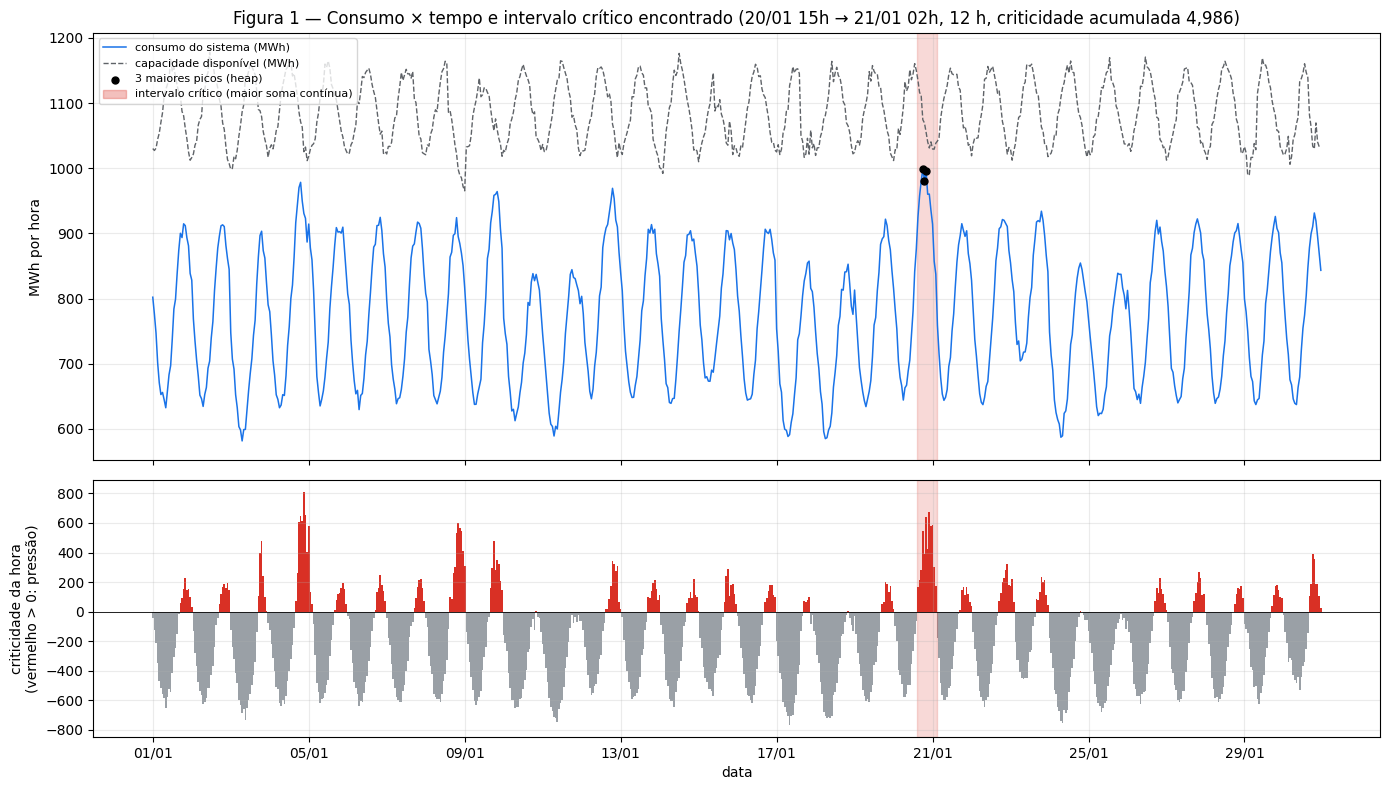

In [9]:
fig1 = figura_serie_temporal(ix, dc, PASTA_FIG / 'fig1_serie_temporal.png'); plt.show()

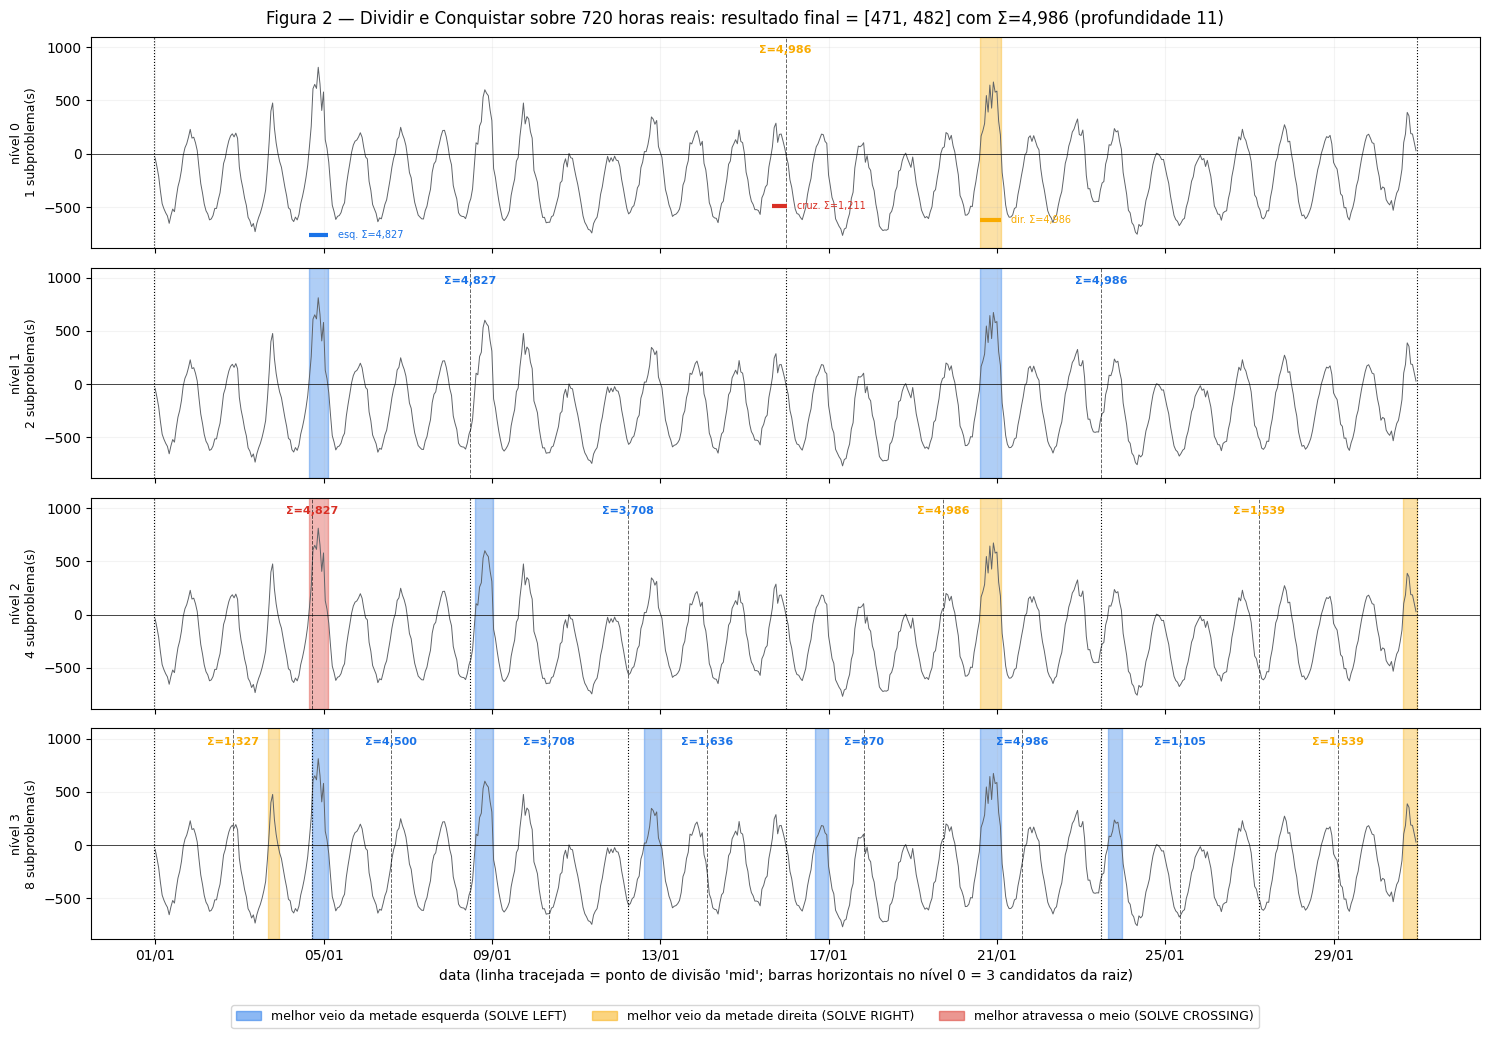

In [10]:
fig2 = figura_divide_conquer(ix, trace, dc, 4, PASTA_FIG / 'fig2_divide_conquer.png'); plt.show()

**Como ler a Figura 2.** Cada painel é um nível da recursão (1, 2, 4 e 8 subproblemas). As linhas tracejadas verticais são os pontos `mid` de cada subproblema (DIVIDE);
a faixa colorida é o melhor intervalo de cada subproblema e a **cor mostra de onde veio**: azul = metade esquerda, amarelo = direita, vermelho = caso que atravessa o meio.
No nível 0 as três barras horizontais são os candidatos da raiz; o COMBINE escolhe o de maior soma. No nível 2, o subproblema mais à esquerda é resolvido pelo caso cruzado (vermelho):
o pico de 05/01 fica exatamente sobre a divisão desse subproblema.

## Parte D — Experimento de escalabilidade

Para cada $n \in \{100, 250, 500, 1000, 2000, 5000\}$ geramos uma série de $n$ horas com o mesmo gerador e medimos: **tempo médio** (`perf_counter`, 1 a 5 repetições),
**operações** contadas pelo próprio algoritmo e **pico de memória** (`tracemalloc`, em execução separada). A força bruta cúbica só roda até $n=500$.
Todos os algoritmos precisam concordar na soma encontrada (o experimento aborta se discordarem). *Esta célula leva cerca de 1 minuto.*

In [11]:
exp = executar_experimento(TAMANHOS_PADRAO, SEED)
print(f"{'algoritmo':22} {'n':>6} {'tempo (ms)':>12} {'operações':>14} {'mem. pico (KiB)':>16}")
for l in exp:
    print(f"{l.algoritmo:22} {l.n:>6} {l.tempo_s*1000:>12.2f} {l.operacoes:>14,} {l.memoria_pico_kib:>16.1f}")

print()
for nome in ALGORITMOS:
    pts = [(l.n, l.tempo_s) for l in exp if l.algoritmo == nome]
    print(f"expoente estimado (log-log) — {nome}: {estimar_expoente(*zip(*pts)):.2f}")

print("\nCrescimento do tempo quando n dobra (1000 → 2000):")
for nome in ("Força bruta O(n²)", "Dividir e Conquistar"):
    t = {l.n: l.tempo_s for l in exp if l.algoritmo == nome}
    print(f"  {nome:22} ×{t[2000]/t[1000]:.2f}")

algoritmo                   n   tempo (ms)      operações  mem. pico (KiB)
Força bruta O(n³)         100         7.07        171,700              0.4
Força bruta O(n²)         100         0.60          5,050              0.4
Dividir e Conquistar      100         0.17            772              0.5
Força bruta O(n³)         250        94.86      2,635,500              0.4
Força bruta O(n²)         250         4.01         31,375              0.4
Dividir e Conquistar      250         0.47          2,244              0.5
Força bruta O(n³)         500       774.15     20,958,500              1.8
Força bruta O(n²)         500        15.82        125,250              0.5
Dividir e Conquistar      500         1.31          4,988              1.4
Força bruta O(n²)        1000        63.48        500,500              0.5
Dividir e Conquistar     1000         2.03         10,976              1.5
Força bruta O(n²)        2000       281.33      2,001,000              0.5
Dividir e Conquistar     

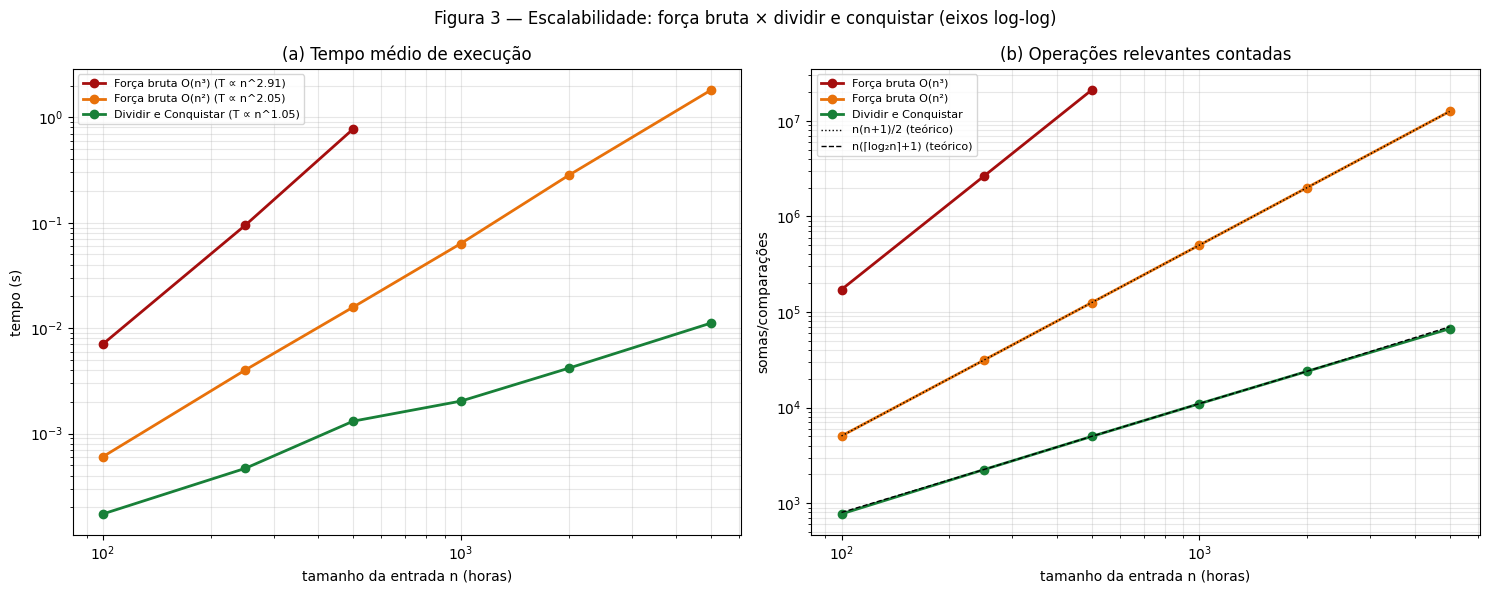

In [12]:
fig3 = figura_escalabilidade(exp, PASTA_FIG / 'fig3_escalabilidade.png'); plt.show()

### Interpretação do experimento

* **Inclinações no gráfico log-log = expoentes.** A regressão dá ≈ 2,9–3,0 para a força bruta cúbica, ≈ 2,0 para a quadrática e ≈ 1,0–1,1 para o dividir e conquistar — exatamente o previsto por $\Theta(n^3)$, $\Theta(n^2)$ e $\Theta(n\log n)$
  (em escala log-log, $n\log n$ parece uma reta com inclinação ligeiramente acima de 1, porque $\log n$ cresce devagar).
* **Dobrar $n$:** a força bruta quadrática leva ≈ 4× mais tempo (entre 4× e 4,7× nas nossas execuções; o excesso vem de efeitos de cache/memória); o dividir e conquistar, ≈ 2× (1,9× a 2,1×). É esse fator, e não o tempo absoluto, que decide o que escala.
* **Operações contadas × teoria:** a quadrática executa *exatamente* $n(n+1)/2$ somas e a cúbica $n(n+1)(n+2)/6$ (a curva pontilhada coincide com os pontos). O D&C fica em ≈ $n(\lceil\log_2 n\rceil+1)$
  (curva tracejada): $n$ elementos por nível × ⌈log₂ n⌉ níveis, mais as $n$ folhas.
* **Tempo × operações:** o tempo segue as operações, mas com constantes diferentes: o D&C paga chamadas recursivas e tuplas em cada operação. Em $n=100$ a razão de tempo entre a quadrática e o D&C (≈ 3×) é bem menor que a razão de operações (≈ 6,5×); em $n=5000$ as duas razões se aproximam (≈ 150× no tempo contra ≈ 190× nas operações). Ou seja: em entradas pequenas a constante do D&C esconde a vantagem assintótica; ela só domina a partir de algumas centenas de horas.
* **Memória:** a força bruta usa memória auxiliar constante ($O(1)$); o D&C usa $O(\log n)$ (pilha de recursão) — o pico medido do D&C cresce de ≈ 0,5 KiB para ≈ 2 KiB (×4) enquanto $n$ cresce ×50 — muito longe de um crescimento linear, coerente com uma pilha de profundidade logarítmica —, enquanto a força bruta fica em ≈ 0,5–1,8 KiB (a oscilação é ruído de objetos do interpretador). O `tracemalloc` só enxerga objetos Python alocados, então é uma aproximação (a pilha de chamadas não é contada integralmente). A série de entrada não entra na conta.
* **Limite prático:** a cúbica leva ≈ 0,8 s em $n=500$; como cresce com $n^3$, em $n=5000$ levaria ≈ 13 minutos (0,8 s × 10³). Por isso foi limitada a $n\le500$.

## Análise Big O

Sejam $n$ o número de horas da série, $R$ o número de registros ($R = 10\,n$ aqui: 5 regiões × 2 unidades).

### Força bruta cúbica
* **Tempo** $T(n)=\sum_{i=0}^{n-1}\sum_{j=i}^{n-1}(j-i+1)=\frac{n(n+1)(n+2)}{6}=\Theta(n^3)$ — três laços aninhados (início, fim, soma do trecho).
* **Espaço** $S(n)=O(1)$: só variáveis escalares (soma, melhor, contadores). Sem recursão, sem estruturas auxiliares.

### Força bruta quadrática
* **Tempo** $T(n)=\sum_{i=0}^{n-1}(n-i)=\frac{n(n+1)}{2}=\Theta(n^2)$ — dois laços; a soma corrente evita o terceiro.
* **Espaço** $S(n)=O(1)$.

### Dividir e conquistar
* **Recorrência:** $T(n)=2\,T(n/2)+\Theta(n)$, com $T(1)=\Theta(1)$. O $\Theta(n)$ vem do caso que atravessa a divisão (dois laços que somam $hi-lo+1$ elementos) e do COMBINE ($O(1)$).
* **Solução (árvore de recursão):** cada nível tem subproblemas cujos tamanhos somam $n$ ⇒ trabalho $\Theta(n)$ por nível; há $\lceil\log_2 n\rceil+1$ níveis ⇒ $T(n)=\Theta(n\log n)$
  (também pelo Teorema Mestre, caso 2: $a=2,\,b=2,\,f(n)=\Theta(n^{\log_b a})$).
* **Espaço:** a recursão desce só por índices (`lo`, `hi`), **sem fatias** — cada quadro é $O(1)$ e a profundidade é $\lceil\log_2 n\rceil+1$ ⇒ $S(n)=O(\log n)$ auxiliar.
  (Ao registrar `trace` para as figuras, guardam-se $n-1$ nós ⇒ $O(n)$ *opcional*, só usado para explicação.)

### Estruturas de dados (pré-processamento, Parte A)
Ordenar os $R$ registros: $O(R\log R)$; construir os índices e a série horária: $O(R)$; somas prefixo: $O(n)$. Espaço $O(R)$.
Depois, cada consulta custa o indicado na tabela da Parte A (ex.: `soma_criticidade` $O(1)$, `indices_do_intervalo` $O(\log n)$).

### Pergunta: se o conjunto crescer de 1.000 para 1.000.000 de registros, qual solução continuaria viável e por quê?

Medimos o D&C em $n=10^6$ e **extrapolamos** a força bruta a partir do tempo medido em $n=5000$ (rodá-la de fato levaria horas).

In [13]:
v = experimento_viabilidade(1_000_000, SEED)
print(f"Dividir e conquistar em n = {v['n_alvo']:,}: {v['tempo_dc_s']:.2f} s | {v['operacoes_dc']:,} operações | profundidade {v['profundidade_dc']}")
print(f"Força bruta O(n²): {v['operacoes_bruta']:,} somas ≈ {v['tempo_bruta_extrapolado_s']:,.0f} s ≈ {v['tempo_bruta_extrapolado_s']/3600:.1f} h "
      f"(extrapolado de n={v['n_ref']}: {v['tempo_bruta_ref_s']:.2f} s, fator (10⁶/{v['n_ref']})²)")

Dividir e conquistar em n = 1,000,000: 2.92 s | 20,951,424 operações | profundidade 21
Força bruta O(n²): 500,000,500,000 somas ≈ 67,470 s ≈ 18.7 h (extrapolado de n=5000: 1.69 s, fator (10⁶/5000)²)


**Resposta.** Só o **dividir e conquistar** continua viável.

* Força bruta: $n$ cresce ×1000 ⇒ o tempo cresce ×$1000^2=10^6$ (quadrática) ou ×$10^9$ (cúbica). São ≈ $5\times10^{11}$ somas: **~20 horas** em Python mesmo na versão quadrática (≈ 200 anos na cúbica). Inviável.
* Dividir e conquistar: $n\log_2 n \approx 2\times10^{7}$ operações ⇒ **poucos segundos**. De $n=1000$ para $n=10^6$ as operações crescem ≈ ×1900 (≈ 1000 × 20/10), e o tempo medido, ≈ ×1300 — não ×$10^6$.
* Memória: a recursão tem só 21 níveis ($\lceil\log_2 10^6\rceil+1$), então a pilha é minúscula; o que ocupa memória é a própria série (1 milhão de inteiros), não o algoritmo. Sem `trace`, o D&C não guarda nada proporcional a $n$.
* Observação honesta: existe um algoritmo **linear** $O(n)$ para este mesmo problema (varredura com soma corrente, “Kadane”) que seria ainda mais rápido; ele não foi usado como solução avaliada,
  apenas como referência de correção nos testes. Entre as abordagens exigidas (força bruta × dividir e conquistar), o D&C é a única escalável — e, ao contrário da varredura linear, o mesmo esqueleto
  (dividir, resolver, combinar com o caso cruzado) é paralelizável nas duas metades.
* Se o milhão de registros fosse de *unidades × horas* (não de horas), a agregação por hora é $O(R)$ e a série resultante seria menor, o que só favorece o D&C.

## Teste de alteração de entrada (preparação para a defesa)

O professor pode mudar um peso, uma capacidade, uma prioridade ou um intervalo. Exemplo: **forçar uma sobrecarga de 6 horas** (horas 300 a 305: consumo = 150% da capacidade em todas as unidades).

**Previsão antes de rodar:** essas horas passam a ter criticidade enorme (excesso penalizado 3× e multiplicado pela prioridade) e positiva. Como o D&C/força bruta somam trechos contínuos,
o novo intervalo ótimo deve **passar a incluir as horas 300–305** (possivelmente estendendo-se às horas vizinhas enquanto somarem positivo) e a soma acumulada deve **aumentar muito**.
O intervalo antigo (20/01) deixa de ser o melhor.

In [14]:
alterados = []
for r in ix.registros:
    h = int((r.timestamp - ix.timestamps[0]).total_seconds() // 3600)
    alterados.append(r._replace(consumo=round(1.5 * r.capacidade, 2)) if 300 <= h <= 305 else r)

ix2 = IndiceEnergia(alterados)
antes = dividir_e_conquistar(ix.serie_criticidade())
depois = dividir_e_conquistar(ix2.serie_criticidade())
print(f"ANTES : [{antes.inicio}, {antes.fim}] {ix.timestamps[antes.inicio]:%d/%m %Hh} → {ix.timestamps[antes.fim]:%d/%m %Hh}  Σ = {antes.soma/ESCALA:,.0f}")
print(f"DEPOIS: [{depois.inicio}, {depois.fim}] {ix2.timestamps[depois.inicio]:%d/%m %Hh} → {ix2.timestamps[depois.fim]:%d/%m %Hh}  Σ = {depois.soma/ESCALA:,.0f}")
assert depois.inicio <= 300 and depois.fim >= 305

ANTES : [471, 482] 20/01 15h → 21/01 02h  Σ = 4,986
DEPOIS: [300, 312] 13/01 12h → 14/01 00h  Σ = 35,138
